---
title: Michelson Interferometers, Modulations, and Transfer Functions - Homework 03
date: 2025-02-16
authors:
  - name: Professor Craig Cahillane
    orcid: 0000-0002-3888-314X
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

This is the third homework assignment for *Lasers and Optomechanics* at Syracuse University.\
**It is due Monday, March 02, 2026 by 5 pm**

**<span style="color:#ff5555;">You will need to complete the questions in this jupyter notebook and submit it via `gitlab`</span>**


In [1]:
%matplotlib widget
from ipywidgets import *

import sympy as sp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

sp.init_printing(use_latex='mathjax')

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": True,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)


# Homodyne Michelson

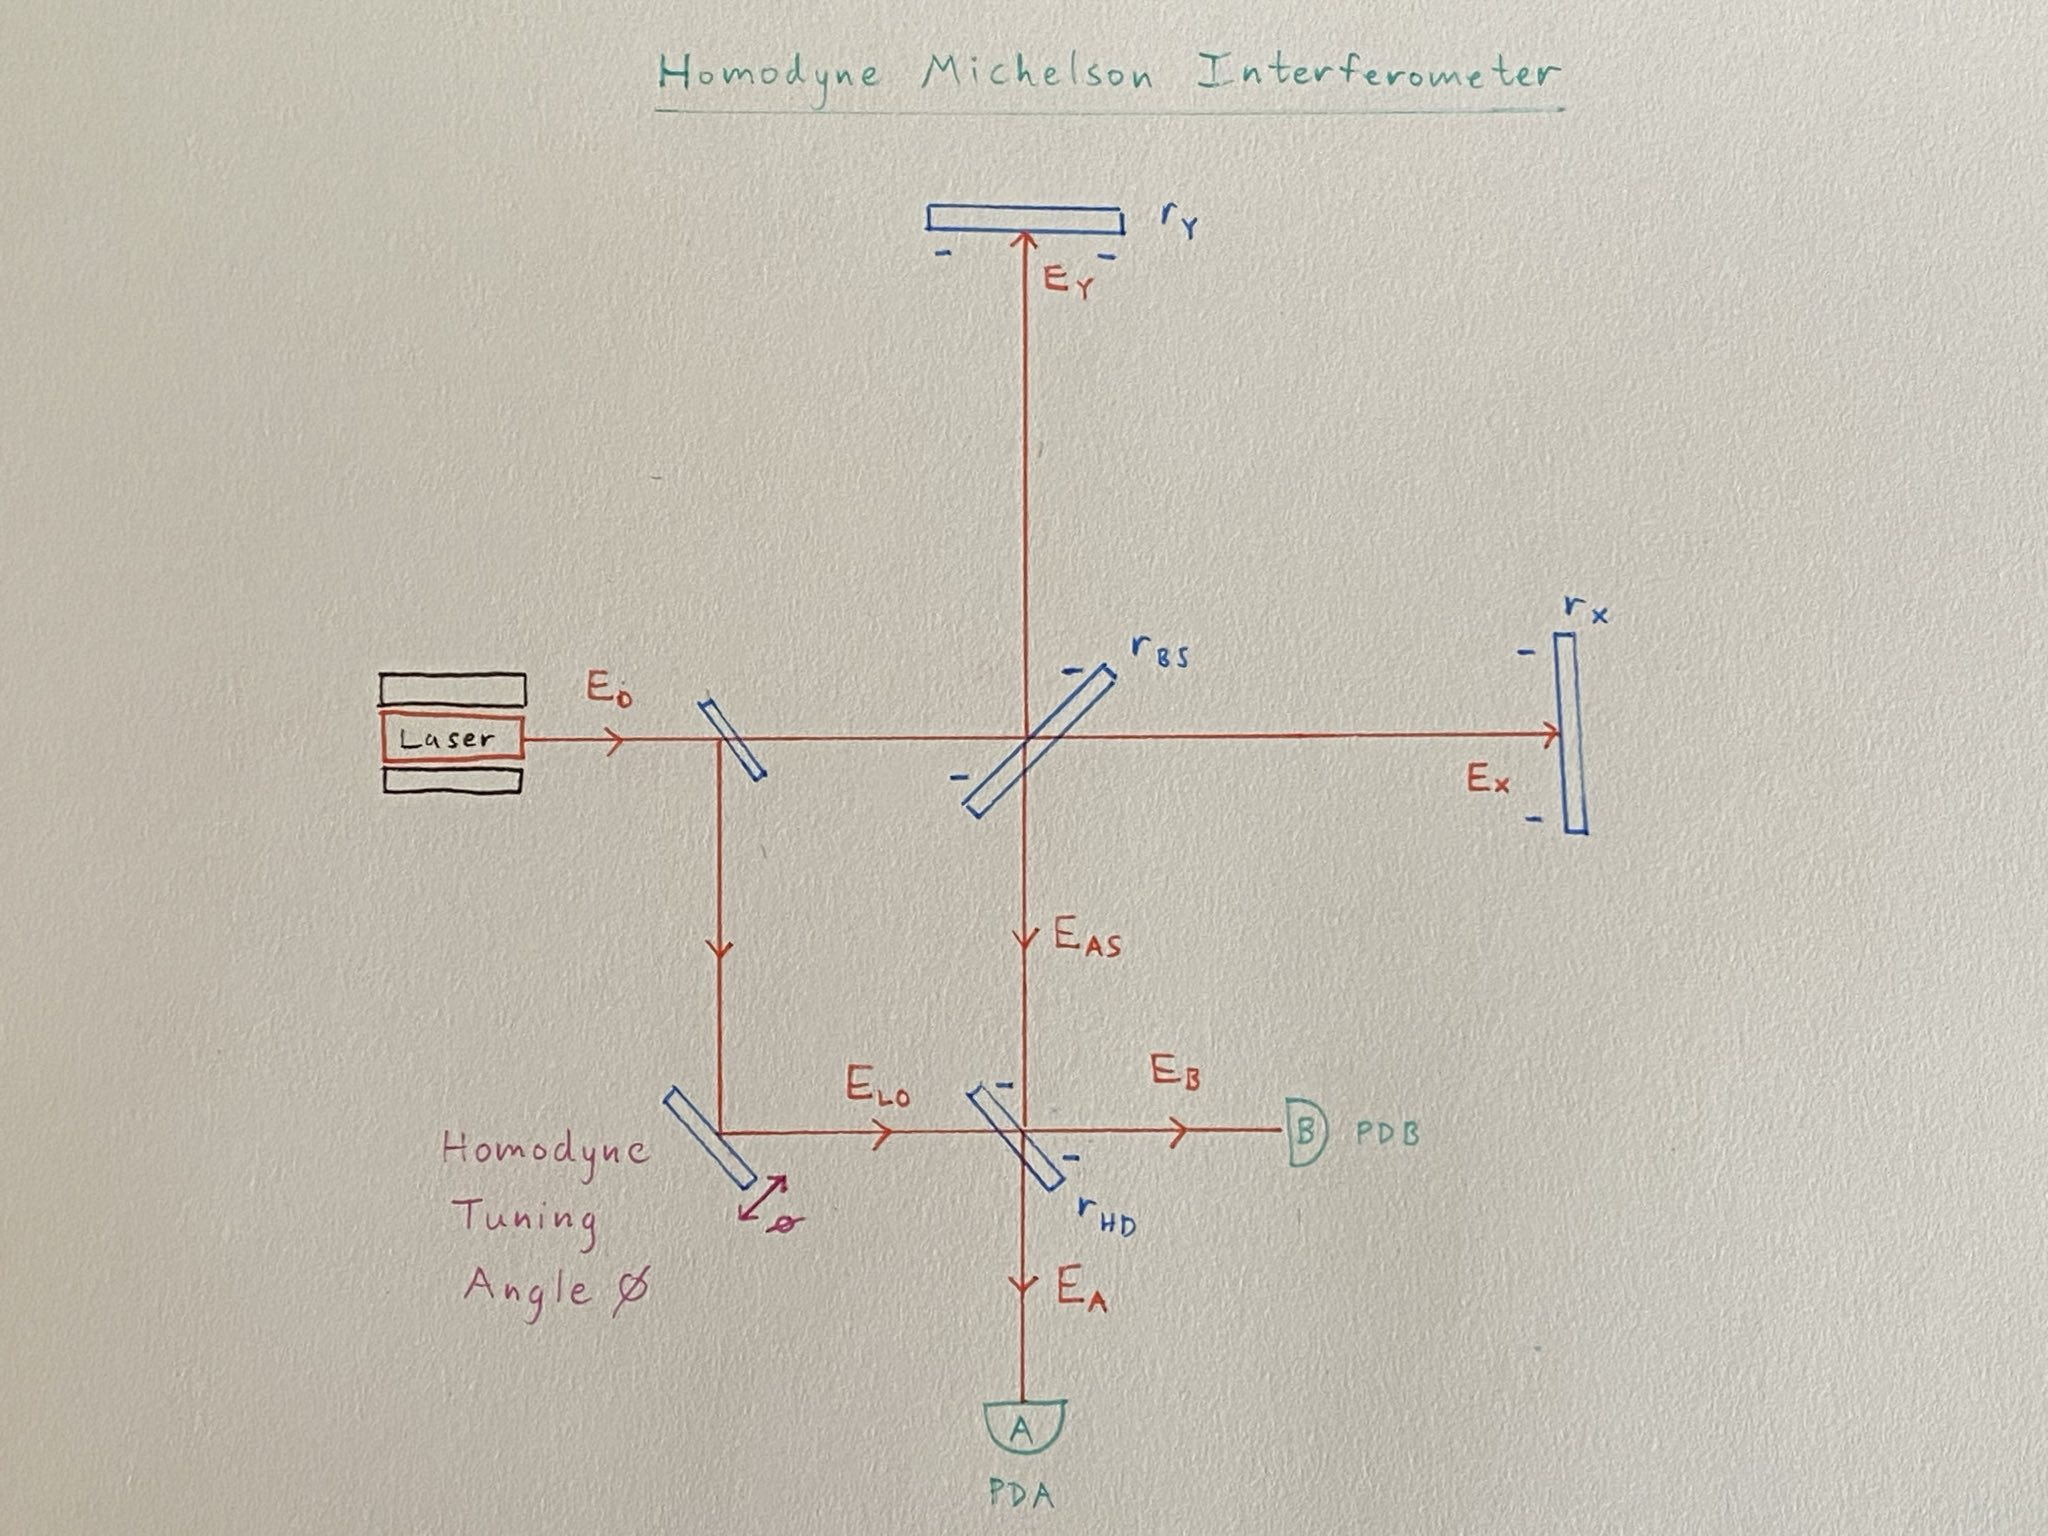

Homodyne Michelson Interferometer Diagram

## Adjacency Matrix
Set up an Adjacency Matrix $\boldsymbol{M}$ for the Homodyne Michelson.\
You may choose any electric fields vector you want, but you have to include the explicitly labeled electric fields.\
The homodyne angle $\phi_\mathrm{HD}$ can be considered as the total phase accrued by the local oscillator field $E_\mathrm{LO}$ in the pick-off path:
\begin{align}
E_\mathrm{LO} = -r_\mathrm{LO} e^{-i \phi_\mathrm{HD}} E_\mathrm{in}
\end{align}

## Electric Field Transfer Functions
Invert your Adjacency Matrix minus the identity $(\boldsymbol{M} - \boldsymbol{I})^{-1}$ to calculate the transfer functions from each electric field to every other electric field.\
Pick out the field transfer functions from the input to the photodetectors $\mathrm{PD}_A$ and $\mathrm{PD}_B$ $\dfrac{E_\mathrm{PDA}}{E_\mathrm{in}}$ and 
$\dfrac{E_\mathrm{PDB}}{E_\mathrm{in}}$.

## Substitutions
Apply the phase change of basis used in class $\phi_d = \dfrac{\phi_x - \phi_y}{2}$ and $\phi_c = \dfrac{\phi_x - \phi_y}{2}$ to your field transfer functions above.\
You may also assume a perfect Michelson beamsplitter $r_\mathrm{BS} = t_\mathrm{BS} = \dfrac{1}{\sqrt{2}}$.

## Power Transfer Functions
Calculate the input to power transfer functions $\dfrac{P_\mathrm{PDA}}{P_\mathrm{in}}$ and $\dfrac{P_\mathrm{PDB}}{P_\mathrm{in}}$.

## Interpretation
How do $\dfrac{P_\mathrm{PDA}}{P_\mathrm{in}}$ and $\dfrac{P_\mathrm{PDB}}{P_\mathrm{in}}$ depend on the homodyne angle $\phi_\mathrm{HD}$, and the common and differential Michelson phase $\phi_d$ and $\phi_c$?\
Can we manipulate the homodyne angle $\phi_\mathrm{HD}$ to detect the differential phase $\phi_d$?\
Can you think of any problems you might run into if you tried to actually set up a homodyned Michelson?

# <span style="color:#ff5500">Homodyne Michelson Solution</span>

## Part A: Adjacency Matrix

First, create the electric field vector $\vec{E}$, with elements below

| Symbol | Description |
|--------|-------------|
| $E_1$ | Input field |
| $E_2$ | Field incident on Michelson beamsplitter |
| $E_3$ | Field in X-arm, incident on end mirror $-r_x$ |
| $E_4$ | Field in Y-arm, incident on end mirror $-r_y$ |
| $E_5$ | Field returning from X-arm to BS |
| $E_6$ | Field returning from Y-arm to BS |
| $E_7$ | Antisymmetric port field $E_\mathrm{as}$ |
| $E_8$ | Local oscillator field $E_\mathrm{lo}$ |
| $E_9$ | Field at photodetector A, $E_A$ |
| $E_{10}$ | Field at photodetector B, $E_B$ |

**Optical elements:**
- $M_1$: Input beamsplitter (splits signal/LO), coefficients $(r_{m1},\, t_{m1})$
- $M_2$: Homodyne steering mirror (imparts LO phase $\phi_\mathrm{hd}$), coefficient $r_{m2}$
- $M_3$: Homodyne beamsplitter (combines $E_\mathrm{as}$ and $E_\mathrm{lo}$), coefficients $(r_\mathrm{hd},\, t_\mathrm{hd})$


The $10\times10$ adjacency matrix, with rows/columns ordered $E_1,\ldots,E_{10}$, is:

$$M = \begin{pmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
t_{m1} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & t_\mathrm{bs} e^{-i\phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & -r_\mathrm{bs} e^{-i\phi_y} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & -r_x e^{-i\phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & -r_y e^{-i\phi_y} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & r_\mathrm{bs} & t_\mathrm{bs} & 0 & 0 & 0 & 0 \\
r_{m1} r_{m2} e^{-i\phi_\mathrm{hd}} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & t_\mathrm{hd} & r_\mathrm{hd} & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & -r_\mathrm{hd} & t_\mathrm{hd} & 0 & 0
\end{pmatrix} \begin{pmatrix}
E_1\\
E_2\\
E_3\\
E_4\\
E_5\\
E_6\\
E_7\\
E_8\\
E_9\\
E_{10}
\end{pmatrix}$$

Reading off this matrix, for example $E_{10} = -r_\mathrm{hd} E_7 + t_\mathrm{hd} E_8$.\
This matches with what we might read off the diagram, with $E_{10} = E_B$, $E_7 = E_{as}$, $E_8 = E_{lo}$, yielding 
$$E_B = -r_\mathrm{hd} E_{as} + t_\mathrm{hd} E_{lo}$$

Inverting this matrix minus the identity gives us our transfer functions:
$$G = (M - I)^{-1}\left(
\begin{array}{cccccccccc}
 -1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 -t_{\text{m1}} & -1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 t_{\text{bs}} t_{\text{m1}} \left(-e^{-i \phi _x}\right) & t_{\text{bs}} \left(-e^{-i \phi _x}\right) & -1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 r_{\text{bs}} t_{\text{m1}} e^{-i \phi _y} & r_{\text{bs}} e^{-i \phi _y} & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 0 \\
 t_{\text{bs}} t_{\text{m1}} r_x e^{-2 i \phi _x} & t_{\text{bs}} r_x e^{-2 i \phi _x} & r_x e^{-i \phi _x} & 0 & -1 & 0 & 0 & 0 & 0 & 0 \\
 r_{\text{bs}} t_{\text{m1}} r_y \left(-e^{-2 i \phi _y}\right) & r_{\text{bs}} r_y \left(-e^{-2 i \phi _y}\right) & 0 & r_y e^{-i \phi _y} & 0 & -1 & 0 & 0 & 0 & 0 \\
 r_{\text{bs}} t_{\text{bs}} t_{\text{m1}} \left(r_x e^{-2 i \phi _x}-r_y e^{-2 i \phi _y}\right) & r_{\text{bs}} t_{\text{bs}} \left(r_x e^{-2 i \phi _x}-r_y e^{-2 i \phi _y}\right) & r_{\text{bs}} r_x e^{-i
   \phi _x} & t_{\text{bs}} r_y e^{-i \phi _y} & -r_{\text{bs}} & -t_{\text{bs}} & -1 & 0 & 0 & 0 \\
 -e^{-i \phi _{\text{hd}}} r_{\text{m1}} r_{\text{m2}} & 0 & 0 & 0 & 0 & 0 & 0 & -1 & 0 & 0 \\
 r_{\text{bs}} t_{\text{bs}} t_{\text{hd}} t_{\text{m1}} r_x e^{-2 i \phi _x}-r_{\text{bs}} t_{\text{bs}} t_{\text{hd}} t_{\text{m1}} r_y e^{-2 i \phi _y}+r_{\text{hd}} \left(-e^{-i \phi _{\text{hd}}}\right)
   r_{\text{m1}} r_{\text{m2}} & r_{\text{bs}} t_{\text{bs}} t_{\text{hd}} \left(r_x e^{-2 i \phi _x}-r_y e^{-2 i \phi _y}\right) & r_{\text{bs}} t_{\text{hd}} r_x e^{-i \phi _x} & t_{\text{bs}} t_{\text{hd}}
   r_y e^{-i \phi _y} & -r_{\text{bs}} t_{\text{hd}} & -t_{\text{bs}} t_{\text{hd}} & -t_{\text{hd}} & -r_{\text{hd}} & -1 & 0 \\
 -r_{\text{bs}} t_{\text{bs}} r_{\text{hd}} t_{\text{m1}} r_x e^{-2 i \phi _x}+r_{\text{bs}} t_{\text{bs}} r_{\text{hd}} t_{\text{m1}} r_y e^{-2 i \phi _y}+t_{\text{hd}} \left(-e^{-i \phi _{\text{hd}}}\right)
   r_{\text{m1}} r_{\text{m2}} & r_{\text{bs}} t_{\text{bs}} r_{\text{hd}} \left(r_y e^{-2 i \phi _y}-r_x e^{-2 i \phi _x}\right) & r_{\text{bs}} r_{\text{hd}} r_x \left(-e^{-i \phi _x}\right) & t_{\text{bs}}
   r_{\text{hd}} r_y \left(-e^{-i \phi _y}\right) & r_{\text{bs}} r_{\text{hd}} & t_{\text{bs}} r_{\text{hd}} & r_{\text{hd}} & -t_{\text{hd}} & 0 & -1 \\
\end{array}
\right)
$$

## Part B: Electric Field Transfer Functions

From our matrix inversion, we can pick off the last two rows and first column elements $G_{9,1}$ and $G_{10,1}$

$$\dfrac{E_A}{E_\mathrm{in}} = G_{9,1}, \qquad \dfrac{E_B}{E_\mathrm{in}} = G_{10,1}$$

\begin{align}
\dfrac{E_A}{E_\mathrm{in}} &= r_{\text{bs}} t_{\text{bs}} t_{\text{hd}} t_{\text{m1}} r_x e^{-2 i \phi _x}-r_{\text{bs}} t_{\text{bs}} t_{\text{hd}} t_{\text{m1}} r_y e^{-2 i \phi _y} - r_{\text{hd}} r_{\text{m1}} r_{\text{m2}} e^{-i \phi _{\text{hd}}}\\
\dfrac{E_B}{E_\mathrm{in}} &= -r_{\text{bs}} t_{\text{bs}} r_{\text{hd}} t_{\text{m1}} r_x e^{-2 i \phi _x}+r_{\text{bs}} t_{\text{bs}} r_{\text{hd}} t_{\text{m1}} r_y e^{-2 i \phi _y} - t_{\text{hd}} r_{\text{m1}} r_{\text{m2}} e^{-i \phi _{\text{hd}}}\\
\end{align}


## Part C: Substitutions

Physically motivated simplifications:

1. **Phase basis change:** $\phi_x = \phi_c + \phi_d$, $\;\phi_y = \phi_c - \phi_d$
2. **Ideal 50:50 Michelson BS:** $t_\mathrm{bs} = r_\mathrm{bs} = 1/\sqrt{2}$
3. **Perfect end mirrors:** $r_x = r_y = 1$,
4. **Perfect steering mirror:** $r_{m2} = 1$
5. **Ideal 50:50 homodyne BS:** $t_\mathrm{hd} = r_\mathrm{hd} = 1/\sqrt{2}$
6. **Ideal 50:50 input BS:** $t_{m1} = r_{m1} = 1/\sqrt{2}$

\begin{align}
\dfrac{E_A}{E_\mathrm{in}} &= \dfrac{1}{4} \left( -e^{-i 2 (\phi_c - \phi_d)} + e^{-i 2 (\phi_c + \phi_d)} - 2 e^{-i \phi_{hd}} \right)\\
\dfrac{E_B}{E_\mathrm{in}} &= \dfrac{1}{4} \left( e^{-i 2 (\phi_c - \phi_d)} - e^{-i 2 (\phi_c + \phi_d)} - 2 e^{-i \phi_{hd}} \right)\\
\end{align}



## Part D: Power Transfer Functions

(Assume that $E_\mathrm{in} = 1~\sqrt{\mathrm{W}}$ and $P_\mathrm{in} = 1~\mathrm{W}$)

Derivation for $P_A$:
\begin{align}
E_A &= \dfrac{1}{4} \left[ -e^{-i 2 (\phi_c - \phi_d)} + e^{-i 2 (\phi_c + \phi_d)} - 2 e^{-i \phi_{hd} } \right]\\
E_A &= \dfrac{1}{4} e^{-i 2 \phi_c} \left[ -e^{i 2 \phi_d} + e^{-i 2 \phi_d} - 2 e^{-i (\phi_{hd} - 2\phi_c) } \right]\\
E_A &= \dfrac{1}{4} e^{-i 2 \phi_c} \left[ -i 2 \sin(2 \phi_d) - 2 e^{-i (\phi_{hd} - 2\phi_c) } \right]\\
E_A &= \dfrac{1}{2} e^{-i 2 \phi_c} \left[ -i \sin(2 \phi_d) - e^{-i (\phi_{hd} - 2\phi_c) } \right]\\~\\
P_A &= \left|E_A\right|^2\\
P_A &= \dfrac{1}{4} \left[ -i \sin(2 \phi_d) - e^{-i (\phi_{hd} - 2\phi_c) } \right] \left[ i \sin(2 \phi_d) - e^{i (\phi_{hd} - 2\phi_c) } \right]\\
P_A &= \dfrac{1}{4} \left[ \sin^2(2 \phi_d) + 1 - i \sin(2 \phi_d) e^{-i (\phi_{hd} - 2\phi_c) } + i \sin(2 \phi_d) e^{i (\phi_{hd} - 2\phi_c) } \right]\\
P_A &= \dfrac{1}{4} \left[ 1 + \sin^2(2 \phi_d) + i \sin(2 \phi_d) (i 2 \sin(\phi_{hd} - 2\phi_c)) \right]\\
P_A &= \dfrac{1}{4} \left[ 1 + \sin^2(2 \phi_d) - 2 \sin(2 \phi_d) \sin(\phi_{hd} - 2\phi_c) \right]\\
P_A &= \dfrac{1}{4} \left[ 1 + \sin^2(2 \phi_d) + 2 \sin(2 \phi_d) \sin(2\phi_c - \phi_{hd}) \right]
\end{align}

The normalised powers $P_A = \left|E_A\right|^2$, $P_B = \left|E_B\right|^2$ are :

$$\boxed{P_A = \frac{1}{4}\!\left[1 + \sin^2(2\phi_d) + 2\sin(2\phi_d)\sin(2\phi_c - \phi_\mathrm{hd})\right]}$$

$$\boxed{P_B = \frac{1}{4}\!\left[1 + \sin^2(2\phi_d) - 2\sin(2\phi_d)\sin(2\phi_c - \phi_\mathrm{hd})\right]}$$

Analyzing the above, what is actually most useful as an error signal is the power sum $P_\mathrm{sum} = P_A + P_B$ and difference $P_\mathrm{diff} = P_A - P_B$:

$$\boxed{P_\mathrm{sum} = \frac{1}{4}\!\left[1 + \sin^2(2\phi_d)\right]}$$

$$\boxed{P_\mathrm{diff} = \sin(2\phi_d)\,\sin(2\phi_c - \phi_\mathrm{hd})}$$

Setting $\phi_\mathrm{hd} = 2\phi_c - \pi/2$ maximises sensitivity to $\phi_d$:

$$P_\mathrm{diff}\big|_\mathrm{opt} = \sin(2\phi_d)$$


## Plots

### Plot 1: Power vs Differential Phase $\phi_d$

Optimal homodyne angle $\phi_\mathrm{hd} = 2\phi_c - \pi/2$, with $\phi_c = 0$.

$P_A - P_B = \sin(2\phi_d)$ crosses zero at $\phi_d = 0$, providing a linear error signal
for **dark-fringe locking**.


In [2]:
phi_d_arr  = np.linspace(-np.pi, np.pi, 1000)
phi_c_arr  = np.linspace(-np.pi, np.pi, 1000)
phi_hd_arr = np.linspace(-np.pi, np.pi, 1000)

In [3]:
def Pa_np(pc,pd,phd): return (3-np.cos(4*pd)+4*np.sin(2*pd)*np.sin(2*pc-phd))/8
def Pb_np(pc,pd,phd): return (3-np.cos(4*pd)-4*np.sin(2*pd)*np.sin(2*pc-phd))/8

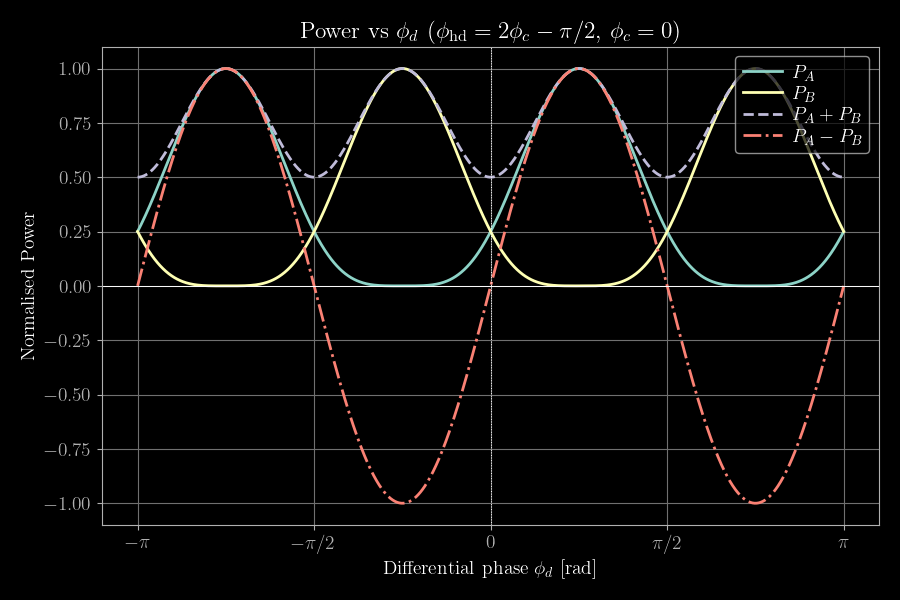

P_A - P_B crosses zero at phi_d = 0: ideal dark-fringe error signal.


In [4]:

# Plot 1 -- vs phi_d, optimal homodyne angle
pc0 = 0.0
phd_opt = 2*pc0 - np.pi/2

fig, ax = plt.subplots()
pa = Pa_np(pc0, phi_d_arr, phd_opt)
pb = Pb_np(pc0, phi_d_arr, phd_opt)
ax.plot(phi_d_arr, pa,    lw=2,          label=r'$P_A$')
ax.plot(phi_d_arr, pb,    lw=2,          label=r'$P_B$')
ax.plot(phi_d_arr, pa+pb, lw=2, ls='--', label=r'$P_A+P_B$')
ax.plot(phi_d_arr, pa-pb, lw=2, ls='-.', label=r'$P_A-P_B$')
ax.axhline(0, color='w', lw=0.7)
ax.axvline(0, color='w', lw=0.7, ls=':')
ax.set_xlabel(r'Differential phase $\phi_d$ [rad]')
ax.set_ylabel('Normalised Power')
ax.set_title(r'Power vs $\phi_d$  ($\phi_\mathrm{hd} = 2\phi_c - \pi/2$, $\phi_c=0$)')
ax.set_xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax.set_xticklabels([r'$-\pi$',r'$-\pi/2$','$0$',r'$\pi/2$',r'$\pi$'])
ax.legend(loc='upper right')
ax.grid()
plt.tight_layout()
# plt.savefig('plot1_vs_phid.png', bbox_inches='tight')
plt.show()
print("P_A - P_B crosses zero at phi_d = 0: ideal dark-fringe error signal.")


### Plot 2: Power vs Common Phase $\phi_c$

$\phi_d = \pi/4$ (bright Michelson), $\phi_\mathrm{hd} = 0$.

The common phase $\phi_c$ redistributes power between detectors A and B,
but leaves the **sum $P_A+P_B$ unchanged**.


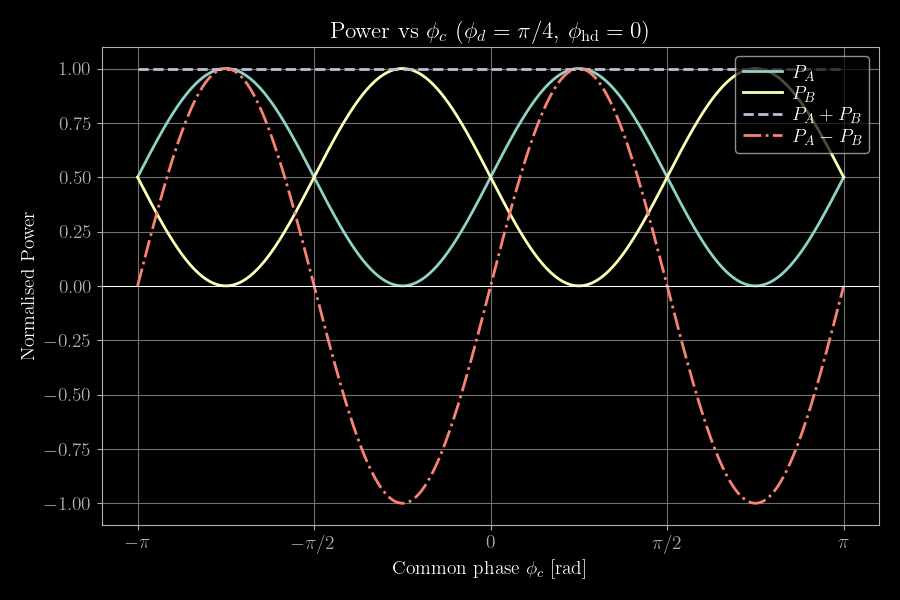

In [5]:
phi_d_bright = np.pi/4

fig2, ax2 = plt.subplots()
pa2 = Pa_np(phi_c_arr, phi_d_bright, 0.0)
pb2 = Pb_np(phi_c_arr, phi_d_bright, 0.0)
ax2.plot(phi_c_arr, pa2,     lw=2,          label=r'$P_A$')
ax2.plot(phi_c_arr, pb2,     lw=2,          label=r'$P_B$')
ax2.plot(phi_c_arr, pa2+pb2, lw=2, ls='--', label=r'$P_A+P_B$')
ax2.plot(phi_c_arr, pa2-pb2, lw=2, ls='-.', label=r'$P_A-P_B$')
ax2.axhline(0, color='w', lw=0.7)
ax2.set_xlabel(r'Common phase $\phi_c$ [rad]')
ax2.set_ylabel('Normalised Power')
ax2.set_title(r'Power vs $\phi_c$  ($\phi_d=\pi/4$, $\phi_\mathrm{hd}=0$)')
ax2.set_xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax2.set_xticklabels([r'$-\pi$',r'$-\pi/2$','$0$',r'$\pi/2$',r'$\pi$'])
ax2.legend(loc='upper right')
ax2.grid()
plt.tight_layout()
# plt.savefig('plot2_vs_phic.png', bbox_inches='tight')
plt.show()


### Plot 3: Power vs Homodyne Angle $\phi_\mathrm{hd}$

$\phi_d = \pi/4$ (bright Michelson), $\phi_c = 0$.

Sweeping $\phi_\mathrm{hd}$ rotates the interference between $E_\mathrm{as}$ and $E_\mathrm{lo}$,
shifting signal between detectors while keeping the sum constant.

> **Note:** This sweep only works on a *bright fringe* -- if the Michelson is dark
> ($E_\mathrm{as}=0$), the LO has nothing to beat against. This motivates the
> **coherent locking field (CLF)**: an RF-modulated sideband co-propagating with
> squeezed light that provides a homodyne angle reference even on the dark fringe.


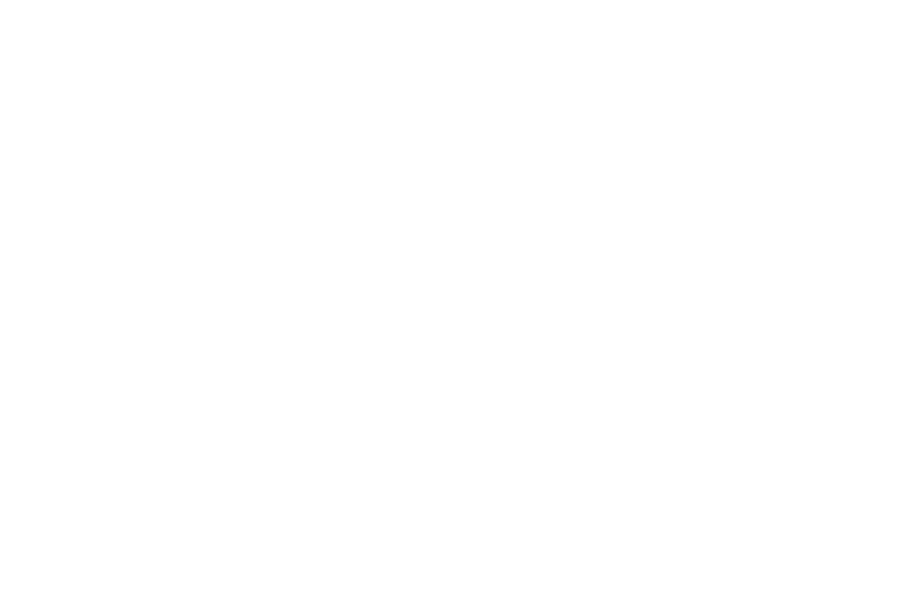

In [6]:
fig, ax3 = plt.subplots()
pa3 = Pa_np(0.0, phi_d_bright, phi_hd_arr)
pb3 = Pb_np(0.0, phi_d_bright, phi_hd_arr)
ax3.plot(phi_hd_arr, pa3,     lw=2,          label=r'$P_A$')
ax3.plot(phi_hd_arr, pb3,     lw=2,          label=r'$P_B$')
ax3.plot(phi_hd_arr, pa3+pb3, lw=2, ls='--', label=r'$P_A+P_B$')
ax3.plot(phi_hd_arr, pa3-pb3, lw=2, ls='-.', label=r'$P_A-P_B$')
ax3.axhline(0, color='w', lw=0.7)
ax3.set_xlabel(r'Homodyne angle $\phi_\mathrm{hd}$ [rad]')
ax3.set_ylabel('Normalised Power')
ax3.set_title(r'Power vs $\phi_\mathrm{hd}$  ($\phi_d=\pi/4$, $\phi_c=0$)')
ax3.set_xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax3.set_xticklabels([r'$-\pi$',r'$-\pi/2$','$0$',r'$\pi/2$',r'$\pi$'])
ax3.legend(loc='upper right')
ax3.grid()
plt.tight_layout()
# plt.savefig('plot3_vs_phihd.png', bbox_inches='tight')
plt.show()


## Extra Credit: Optimal Input Beamsplitter Ratio

Relaxing the 50:50 assumption on $M_1$ (keep $r_{m1}$, $t_{m1}$ free,
$r_{m1}^2 + t_{m1}^2 = 1$), gives new expressions for $E_A$ and $E_B$:

\begin{align}
E_A &= \frac{e^{-i \left(2 \phi _c+2 \phi _d+\phi _{\text{hd}}\right)} \left(-2 r_{\text{m1}} e^{2 i \left(\phi _c+\phi _d\right)}-t_{\text{m1}} e^{i \left(4 \phi _d+\phi _{\text{hd}}\right)}+e^{i \phi _{\text{hd}}}
   t_{\text{m1}}\right)}{2 \sqrt{2}}\\
E_B &=  \frac{e^{-i \left(2 \phi _c+2 \phi _d+\phi _{\text{hd}}\right)} \left(-2 r_{\text{m1}} e^{2 i \left(\phi _c+\phi _d\right)}+t_{\text{m1}} e^{i \left(4 \phi _d+\phi _{\text{hd}}\right)}-e^{i \phi _{\text{hd}}}
   t_{\text{m1}}\right)}{2 \sqrt{2}}
\end{align}

Turning the crank:

\begin{align}
P_A &= \frac{1}{4} \left(4 r_{\text{m1}} t_{\text{m1}} \sin \left(2 \phi _d\right) \sin \left(2 \phi _c-\phi _{\text{hd}}\right)-t_{\text{m1}}^2 \cos \left(4 \phi _d\right)+2 r_{\text{m1}}^2+t_{\text{m1}}^2\right)\\
P_B &= \frac{1}{4} \left(-t_{\text{m1}} \left(4 r_{\text{m1}} \sin \left(2 \phi _d\right) \sin \left(2 \phi _c-\phi _{\text{hd}}\right)+t_{\text{m1}} \cos \left(4 \phi _d\right)\right)+2
   r_{\text{m1}}^2+t_{\text{m1}}^2\right)\\
P_A + P_B &= \frac{1}{2} \left(-t_{\text{m1}}^2 \cos \left(4 \phi _d\right)+2 r_{\text{m1}}^2+t_{\text{m1}}^2\right)\\
P_A - P_B &= 2 r_{\text{m1}} t_{\text{m1}} \sin \left(2 \phi _d\right) \sin \left(2 \phi _c-\phi _{\text{hd}}\right)\\
\end{align}

At the optimal homodyne angle $\phi_\mathrm{hd} = 2\phi_c - \pi/2$, the
differential signal becomes:

$$P_\mathrm{diff} = 2 r_{\text{m1}} t_{\text{m1}} \sin \left(2 \phi _d\right)$$

Maximising over $T_{m1} \equiv t_{m1}^2$ (with $r_{m1} = \sqrt{1-T_{m1}}$):

$$\dfrac{d}{dT_{m1}}\!\left[\sqrt{1-T_{m1}}\sqrt{T_{m1}}\right] = 0\\~\\
\frac{\sqrt{1-T_{\text{m1}}}}{\sqrt{T_{\text{m1}}}}-\frac{\sqrt{T_{\text{m1}}}}{\sqrt{1-T_{\text{m1}}}} = 0\\~\\
\;\Rightarrow\; T_{m1} = 0.5$$

A **50:50 input beamsplitter** gives the maximum sensitivity to differential phase.


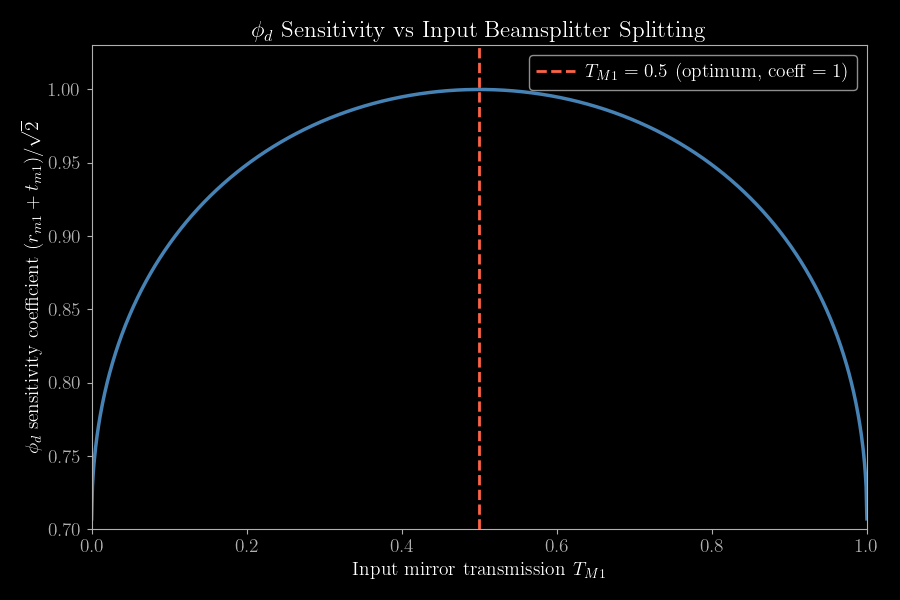

Maximum sensitivity = 1.000000 at Tm1 = 0.499


In [8]:
Tm1 = np.linspace(0, 1, 1000)
coeff = (np.sqrt(1-Tm1) + np.sqrt(Tm1)) / np.sqrt(2)

fig, ax4 = plt.subplots()
ax4.plot(Tm1, coeff, 'steelblue', lw=2.5)
ax4.axvline(0.5, color='tomato', ls='--', lw=2,
           label=r'$T_{M1}=0.5$ (optimum, coeff $=1$)')
ax4.set_xlabel(r'Input mirror transmission $T_{M1}$')
ax4.set_ylabel(r'$\phi_d$ sensitivity coefficient $(r_{m1}+t_{m1})/\sqrt{2}$')
ax4.set_title(r'$\phi_d$ Sensitivity vs Input Beamsplitter Splitting')
ax4.set_xlim(0,1); ax4.set_ylim(0.70, 1.03)
ax4.legend()
plt.tight_layout()
# plt.savefig('plot4_extra_credit.png', bbox_inches='tight')
plt.show()
print(f"Maximum sensitivity = {max(coeff):.6f} at Tm1 = {Tm1[np.argmax(coeff)]:.3f}")


# Asymmetric Michelson

Suppose you have a Michelson interferometer with the X-arm much longer than the Y-arm: 
$$L_x > L_y$$
In this problem, we will calculate the full frequency response transfer functions of the Michelson
$$\dfrac{P_\mathrm{as}}{\phi_\mathrm{CARM}}(\omega) \quad \mathrm{and} \quad
\dfrac{P_\mathrm{as}}{\phi_\mathrm{DARM}}(\omega)$$

I recommend using an algebra helper like *Mathematica* or *sympy* for this problem. 
You may convert your answers to LaTeX using *TeXform* in *Mathematica* or some such similar function for sympy.

## Field tranfer functions 
Derive the electric field transfer functions for the following:
\begin{align}
\dfrac{E_\mathrm{x}}{E_\mathrm{in}}, \dfrac{E_\mathrm{y}}{E_\mathrm{in}}, \dfrac{E_\mathrm{as}}{E_\mathrm{in}}
\end{align}
where $E_\mathrm{in}$ is the input electric field $E_0 e^{i \omega_0 t}$,\
$E_\mathrm{x}$ is the field *reflected from* the X-arm mirror,\
$E_\mathrm{y}$ is the field *reflected from* the Y-arm mirror,\
and $E_\mathrm{as}$ is the field at the antisymmetric (or transmission) port.

Use $r_\mathrm{bs}, t_\mathrm{bs}$ for the beamsplitter reflection and transmission,\
$r_\mathrm{x}, r_\mathrm{y}$ for the X and Y mirror reflections, and\
$\phi_x, \phi_y$ for the single-pass phase accrued by the field as it propagates in the X-arm or Y-arm.

## End Mirror Modulation
Now, suppose we apply some common modulation to both end mirrors:
$$\phi_c(t) = \phi_x(t) = \phi_y(t) = \Gamma \cos(\omega t)$$
Write what the new arm reflected transfer functions are for:
$$\dfrac{E_\mathrm{x}}{E_\mathrm{in}}, \dfrac{E_\mathrm{y}}{E_\mathrm{in}}$$
*Hint: Remember that you should end up with three distinct fields at $\omega_0$ and $\omega_0 \pm \omega$* 

## Propagate to the antisymmetric port
Propagate your new transfer functions to the antisymmetric port, 
and compute a new $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$.

Be careful here.  
Consider carefully what $k = \omega/c$ is for each of your electric fields as they propagate back to the beamsplitter, accruing some phase $\phi = -k L$.\
Should each field accrue the same phase?

## Calculate the power response
Calculate the power response to the common motion 
$\dfrac{P_\mathrm{as}}{P_\mathrm{in}}$.

This is a lot of algebra, I recommend *Mathematica* or *sympy* to help you make sure you get things right here.\
You may find it useful to express your arm phases in the common and differential bases again, since you have already incorporated the time-dependent term $\Gamma \cos(\omega t)$ as two additional sideband terms:
$$\phi_x = \phi_c + \phi_d, \qquad \phi_y = \phi_c - \phi_d$$

You may assume an ideal beamsplitter
$$r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}$$
and balanced arms
$$r_\mathrm{x} = t_\mathrm{y}$$
and small modulation from the end mirrors
$$\Gamma^2 \approx 0$$

*Answer:*
$$
\dfrac{P_\mathrm{as}}{P_\mathrm{in}} = r_x^2 \left[ 
  \sin^2(2 \phi_d) - 2 \Gamma \sin (4 \phi_d) \sin \left(\dfrac{\omega \phi_d}{\omega_0}\right) \sin     \left(\omega t+\frac{\omega \phi_c}{\omega_0}\right) 
\right]
$$

## Demodulate the power term
Calculate 
$$P_\mathrm{as}^\mathrm{DC}, \, P_\mathrm{as}^I, \, P_\mathrm{as}^Q$$
by integrating $P_\mathrm{as}$ over one cycle of $\omega t$ while multiplying by $1, \cos(\omega t)$ and $\sin(\omega t)$, respectively.

Does your answer for $P_\mathrm{as}^\mathrm{DC}$ seem familiar?

## Caluculate the Frequency Response to CARM motion in an Asymmetric Michelson
Calculate the frequency response
$$ P_\mathrm{as}(\omega) = P_\mathrm{as}^I(\omega) + i P_\mathrm{as}^Q(\omega)$$
to CARM motion $\Gamma$.

Plot the magnitude and phase for $\dfrac{P_\mathrm{as}}{\Gamma}(\omega)$.

Assume 
\begin{align}
r_x &= 1\\
L_x &= 1000~\mathrm{m}\\
L_y &= 1~\mathrm{m}\\
\lambda &= 1064~\mathrm{nm}
\end{align}


# <span style="color:#ff5500">Asymmetric Michelson Solution</span>

## Part A: Electric Field Transfer Functions

The field transfer functions for the Michelson are
\begin{align}
\dfrac{E_\mathrm{x}}{E_\mathrm{in}} &=  -r_x t_{bs} e^{-i \phi_x} \\
\dfrac{E_\mathrm{y}}{E_\mathrm{in}} &=   r_y r_{bs} e^{-i \phi_y} \\
\dfrac{E_\mathrm{as}}{E_\mathrm{in}} &= -r_x r_{bs} t_{bs} e^{-i 2 \phi_x} + r_y r_{bs} t_{bs} e^{-i 2 \phi_y}
\end{align}
where $E_\mathrm{in} = E_0 e^{i \omega_0 t}$ is the input electric field,\ 
and $\phi_x = k L_x$ and $\phi_y = k L_y$ are the single pass phase accrued from traversing the arms.\
For us, $L_x > L_y$, so the raw amount of phase accrued in each arm is very different,but our basis breakdown still works.\
We can still write down $\phi_c = \phi_x + \phi_y$ and $\phi_d = \phi_x - \phi_y$, and assuming $r_y = r_x$, rewrite $E_{as}$ in the new basis:
\begin{align}
\dfrac{E_\mathrm{as}}{E_\mathrm{in}} &= E_0 e^{i \omega_0 t} \left(i e^{-i 2 \phi_c} r_x \sin(2 \phi_d) \right)
\end{align}

For the rest of this problem, $\phi_x$ and $\phi_y$ will be broken down into a DC term $\phi_{x0}, \phi_{y0}$, and an AC, or modulating term $\phi_x(t),\phi_y(t)$:
\begin{align}
\phi_x = \phi_{x0} + \phi_x(t)\\
\phi_y = \phi_{y0} + \phi_y(t)
\end{align}

## Part B: Modulation applied to the end mirrors

From class, we saw that mirror motion is equivalent to phase modulation.\
Here we apply a common phase modulation of $\phi_c(t) = 2 \Gamma \cos(\omega t)$,\
so $\phi_x(t) = \phi_y(t) = \Gamma \cos(\omega t)$,\
where $\Gamma$ is the modulation depth in radians,\
$\omega$ is the modulation frequency in radians/second,\
and $t$ is time.

For the beam immediately reflected off the X-arm, we get three frequencies of light coming back, at $\omega_0$, and $\omega_0 \pm \omega$:
\begin{align}
E_x(t) &= E_\mathrm{in} (-r_x t_{bs} \exp[-i \phi_x])\\
E_x(t) &= E_\mathrm{in} (-r_x t_{bs} \exp[-i ( \phi_{x0} + \phi_x(t) ) ])\\
E_x(t) &= E_0 e^{i \omega_0 t} \left(-r_x t_{bs}  e^{-i \phi_{x0}} \exp[-i \Gamma \cos(\omega t)] \right) \\
E_x(t) &= E_0 e^{i \omega_0 t} \left(-r_x t_{bs}  e^{-i \phi_{x0}} \left( 1 + i \dfrac{\Gamma}{2} e^{i \omega t} + i \dfrac{\Gamma}{2} e^{-i \omega t} \right) \right)\\
E_x(t) &= - E_0 r_x t_{bs} e^{-i \phi_{x0}}  \left( e^{i \omega_0 t} + i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} + i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} \right) 
\end{align}

Notice that *all* the beams have experienced the same phase delay $\phi_{x0} = k L_x = \omega_0 L_x / c$ at the end mirror,\
represented by this common coefficient $e^{-i \phi_{x0}}$,\
because during the time the beam propogated to the end mirror, there was only one frequency of light $\omega_0$.


Similarly for the Y-arm:
\begin{align}
E_y(t) &= E_\mathrm{in} (r_y r_{bs} \exp[-i \phi_y])\\
E_y(t) &= E_\mathrm{in} (r_y r_{bs} \exp[-i ( \phi_{y0} + \phi_y(t) ) ])\\
E_y(t) &= E_0 e^{i \omega_0 t} \left(r_y r_{bs}  e^{-i \phi_{y0}} \exp[-i \Gamma \cos(\omega t)] \right) \\
E_y(t) &= E_0 e^{i \omega_0 t} \left(r_y r_{bs}  e^{-i \phi_{y0}} \left( 1 + i \dfrac{\Gamma}{2} e^{i \omega t} + i \dfrac{\Gamma}{2} e^{-i \omega t} \right) \right)\\
E_y(t) &= E_0  r_y r_{bs} e^{-i \phi_{y0}}  \left( e^{i \omega_0 t} + i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} + i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} \right) 
\end{align}

In the last step for both, I distributed the $e^{i \omega_0 t}$ term to each of the three fields to emphasize their actual propagation frequency. 



## Part C: The Dark Port Field $E_{as}$

Now, let's propogate the beams back to the beamsplitter.\
We need to calculate 
$$E_{as} = r_{bs} E_{x2} + t_{bs} E_{y2}$$
where $E_{x2}$ and $E_{y2}$ are the beams incident on the backside of the beamsplitter.

### X-arm
First we'll focus on calculating $E_{x2}$ from our $E_x$ above.
The key difference here is we have our three beams propogating back to the beamsplitter across the same space, but now will experience different phase accretion.

Recall that the propagation coefficient is $e^{-i k L_x}$.
In this case, we have three different $k$, because $k = \Omega / c$, and we have $\Omega = {\omega_0, \omega_0 + \omega, \omega_0 - \omega}$.\
(Here I used $\Omega$ to represent a generalized frequency, because $\omega$ is already taken for our modulation frequency).

So, our carrier, upper sideband, and lower sideband will experience three different phases going back to the beamsplitter from the X-arm end mirror:
\begin{align}
\text{Carrier}: \quad &\phi_{x0} = \dfrac{\omega_0 L_x}{c} \\
\text{Upper Sideband}: \quad  &\phi_{x,\mathrm{usb}} = \dfrac{(\omega_0 + \omega) L_x}{c} \\
\text{Lower Sideband}: \quad  &\phi_{x,\mathrm{lsb}} = \dfrac{(\omega_0 - \omega) L_x}{c} 
\end{align}
so the carrier accrues the exact same phase going back to the beamsplitter,
but the sidebands accrue more or less phase.

I like to rewrite the sideband phases accrued in terms of the carrier DC phase $\phi_{x0}$ and $\omega$:
\begin{align}
\text{Upper Sideband}: \quad  \phi_{x,\mathrm{usb}} &= \dfrac{(\omega_0 + \omega) L_x}{c}\\
&= \dfrac{\omega_0 L_x}{c} + \dfrac{\omega L_x}{c}\\
&= \phi_{x0} + \dfrac{\omega}{\omega_0} \phi_{x0}\\
&= \phi_{x0} \left(1 + \dfrac{\omega}{\omega_0} \right) \\~\\
\text{Lower Sideband}: \quad  \phi_{x,\mathrm{lsb}} &= \phi_{x0} \left(1 - \dfrac{\omega}{\omega_0} \right)
\end{align}

Reproducing our expression for $E_{x}$:
\begin{align}
E_x(t) &= - E_0 r_x t_{bs} e^{-i \phi_{x0}}  \left( e^{i \omega_0 t} + i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} + i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} \right) 
\end{align}

Now we apply our additional propagation delays to each beam to get $E_{x2} = e^{-i k L} E_{x}$:
\begin{align}
E_{x2}(t) &= - E_0 r_x t_{bs} e^{-i \phi_{x0}}  \left[ e^{i \omega_0 t} \exp{(-i \phi_{x0})} + i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} \exp{\left(-i \phi_{x,\mathrm{usb}}\right)} + i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} \exp{\left(-i \phi_{x,\mathrm{lsb}}\right)} \right]\\
E_{x2}(t) &= - E_0 r_x t_{bs} e^{-i \phi_{x0}}  \left[ e^{i \omega_0 t} \exp{(-i \phi_{x0})} + i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} \exp{\left(-i \phi_{x0} \left(1 + \dfrac{\omega}{\omega_0} \right)\right)} + i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} \exp{\left(-i \phi_{x0} \left(1 - \dfrac{\omega}{\omega_0} \right)\right)} \right]
\end{align}
Factoring out the common $e^{-i \phi_{x0}}$ term gives:
\begin{align}
E_{x2}(t) &= - E_0 r_x t_{bs} e^{-i 2 \phi_{x0}}  \left[ e^{i \omega_0 t} 
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} e^{-i \phi_{x0} \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} e^{i \phi_{x0} \omega / \omega_0}
\right]
\end{align}

### Y-arm
We get the exact same thing for the Y-arm:
\begin{align}
E_{y2}(t) &=  E_0 r_y r_{bs} e^{-i 2 \phi_{y0}}  \left[ e^{i \omega_0 t} 
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} e^{-i \phi_{y0} \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} e^{i \phi_{y0} \omega / \omega_0}
\right]
\end{align}

### AS beam

\begin{align}
E_{as} =& r_{bs} E_{x2} + t_{bs} E_{y2}\\
E_{as} = -&r_{bs} E_0 r_x t_{bs} e^{-i 2 \phi_{x0}}  \left[ e^{i \omega_0 t} 
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} e^{-i \phi_{x0} \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} e^{i \phi_{x0} \omega / \omega_0}
\right]\\
+& t_{bs} E_0 r_y r_{bs} e^{-i 2 \phi_{y0}}  \left[ e^{i \omega_0 t} 
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} e^{-i \phi_{y0} \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} e^{i \phi_{y0} \omega / \omega_0}
\right]\\
\end{align}

What we end up with, is *three distinct interference terms*, one for each of $\omega_0$, $\omega_0 + \omega$, $\omega_0 - \omega$.\
Each of these interacts with the Michelson in a slightly different manner,
but are individually comparable.

If we make all the usual assumptions at this point here, like the basis change
$$\phi_{x0} = \phi_{c0} + \phi_{d0}, \qquad \phi_{y0} = \phi_{c0}- \phi_{d0}$$
an ideal beamsplitter:
$$r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}$$
and balanced arms
$$r_\mathrm{x} = r_\mathrm{y}$$

We can write $E_{as}$ above as
\begin{align}
E_{as} = -&\dfrac{1}{2} E_0 r_x e^{-i 2 (\phi_{c0} + \phi_{d0}) } \left[ e^{i \omega_0 t} 
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} e^{-i (\phi_{c0} + \phi_{d0}) \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} e^{i (\phi_{c0} + \phi_{d0}) \omega / \omega_0}
\right]\\
+& \dfrac{1}{2} E_0 r_x e^{-i 2 (\phi_{c0} - \phi_{d0})}  \left[ e^{i \omega_0 t} 
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 + \omega) t} e^{-i (\phi_{c0} - \phi_{d0}) \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{i (\omega_0 - \omega) t} e^{i (\phi_{c0} - \phi_{d0}) \omega / \omega_0}
\right]\\
\end{align}

Pulling out the common factors, and distribute the differential factors, in prep for converting to trig expressions where possible:
\begin{align}
E_{as} = -&\dfrac{1}{2} E_0 r_x e^{i \omega_0 t} e^{-i 2 \phi_{c0} } \left[ e^{-i 2 \phi_{d0} }
+ i \dfrac{\Gamma}{2} e^{ i \omega t} e^{-i (2 + \omega / \omega_0) \phi_{d0} } e^{-i \phi_{c0} \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{-i \omega t} e^{-i (2 - \omega / \omega_0) \phi_{d0} } e^{ i \phi_{c0} \omega / \omega_0}
\right]\\
+& \dfrac{1}{2} E_0 r_x e^{i \omega_0 t}  e^{-i 2 \phi_{c0} }  \left[ e^{i 2 \phi_{d0} }
+ i \dfrac{\Gamma}{2} e^{ i \omega t} e^{i (2 + \omega / \omega_0) \phi_{d0} } e^{-i \phi_{c0} \omega / \omega_0}
+ i \dfrac{\Gamma}{2} e^{-i \omega t} e^{i (2 - \omega / \omega_0) \phi_{d0} } e^{ i \phi_{c0} \omega / \omega_0}
\right]\\
\end{align}

Using the above equation, compare the first terms in the brackets.\
This corresponds to carrier.\
Combining those terms gives 
\begin{align}
E_{as,0} &= \dfrac{1}{2} E_0 r_x e^{i \omega_0 t} e^{-i 2 \phi_{c0} } \left[ -e^{-i 2 \phi_{d0} } + e^{i 2 \phi_{d0} }\right]\\
E_{as,0} &= \dfrac{1}{2} E_0 r_x e^{i \omega_0 t} e^{-i 2 \phi_{c0} } (2 i \sin(2 \phi_{d0}))\\~\\
E_{as,0} &= i E_0 r_x e^{i \omega_0 t} e^{-i 2 \phi_{c0} } \sin(2 \phi_{d0})
\end{align}

which actually recovers the typical Michelson response.

But we also have the upper and lower sideband terms, which are actually very similar, just with bigger arguments in the exponentials.
Consider the upper sideband term $\omega_0 + \omega$, the second terms in the brackets:
\begin{align}
E_{as,\mathrm{usb}} &= \dfrac{1}{2} E_0 r_x e^{i \omega_0 t} e^{-i 2 \phi_{c0} } \left[ 
-i \dfrac{\Gamma}{2} e^{ i \omega t} e^{-i (2 + \omega / \omega_0) \phi_{d0} } e^{-i \phi_{c0} \omega / \omega_0} 
+ i \dfrac{\Gamma}{2} e^{ i \omega t} e^{i (2 + \omega / \omega_0) \phi_{d0} } e^{-i \phi_{c0} \omega / \omega_0}
\right]\\
E_{as,\mathrm{usb}} &= \dfrac{i \Gamma}{4} E_0 r_x e^{i (\omega_0 + \omega) t} e^{-i (2 + \omega / \omega_0) \phi_{c0} } \left[
- e^{-i (2 + \omega / \omega_0) \phi_{d0} }
+ e^{i (2 + \omega / \omega_0) \phi_{d0} }
\right]\\
E_{as,\mathrm{usb}} &= \dfrac{i \Gamma}{4} E_0 r_x e^{i (\omega_0 + \omega) t} e^{-i (2 + \omega / \omega_0) \phi_{c0} } \left[
2 i \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) \right]\\
E_{as,\mathrm{usb}} &= -\dfrac{\Gamma}{2} E_0 r_x e^{i (\omega_0 + \omega) t} e^{-i (2 + \omega / \omega_0) \phi_{c0} } \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) 
\end{align}

The lower sideband $E_{as,\mathrm{lsb}}$ is the same as the upper sideband, combine the third terms in the brackets above, or just flip the sign of $\omega$ terms in $E_{as,\mathrm{usb}}$:
\begin{align}
E_{as,\mathrm{lsb}} &= -\dfrac{\Gamma}{2} E_0 r_x e^{i (\omega_0 - \omega) t} e^{-i (2 - \omega / \omega_0) \phi_{c0} } \sin\left(\left(2 - \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) 
\end{align}

Combining it all together gives us our scary-looking term:
\begin{align}
E_{as} =& E_{as,0} + E_{as,\mathrm{usb}} + E_{as,\mathrm{lsb}}\\
E_{as} =& i E_0 r_x e^{i \omega_0 t} e^{-i 2 \phi_{c0} } \sin(2 \phi_{d0})\\
-& \dfrac{\Gamma}{2} E_0 r_x e^{i (\omega_0 + \omega) t} e^{-i (2 + \omega / \omega_0) \phi_{c0} } \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) \\
-& \dfrac{\Gamma}{2} E_0 r_x e^{i (\omega_0 - \omega) t} e^{-i (2 - \omega / \omega_0) \phi_{c0} } \sin\left(\left(2 - \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) 
\end{align}

## Part D: The Power of the Dark Port $P_{as}(t)$

Now we must find the power in the dark port $P_{as}(t) = |E_{as}(t)|^2$.

At this point, we declare that our modulation is small, so $\Gamma^2 \approx 0$.

### General Modulation
It helps to consider a more general picture, so let's look at our carrier, USB, LSB breakdown from before, and calculate a general power term using that:
\begin{align}
E_{as} &= E_{as,0} + E_{as,\mathrm{usb}} + E_{as,\mathrm{lsb}}\\
P_{as} &= |E_{as,0} + E_{as,\mathrm{usb}} + E_{as,\mathrm{lsb}}|^2 \\
P_{as} &= |E_{as,0}|^2 + |E_{as,\mathrm{usb}}|^2 + |E_{as,\mathrm{lsb}}|^2 \\
&+ E_{as,0}^* E_{as,\mathrm{usb}} + E_{as,0} E_{as,\mathrm{lsb}}^* + E_{as,0} E_{as,\mathrm{usb}}^* + E_{as,0}^* E_{as,\mathrm{lsb}} \\
&+ E_{as,\mathrm{usb}} E_{as,\mathrm{lsb}}^* + E_{as,\mathrm{usb}}^* E_{as,\mathrm{lsb}}
\end{align}
The first row $|E_{as,0}|^2 + |E_{as,\mathrm{usb}}|^2 + |E_{as,\mathrm{lsb}}|^2$ are the DC terms,\
the second row $E_{as,0}^* E_{as,\mathrm{usb}} + E_{as,0} E_{as,\mathrm{lsb}}^* + E_{as,0} E_{as,\mathrm{usb}}^* + E_{as,0}^* E_{as,\mathrm{lsb}}$ are the 1$\omega$ terms which oscillate at $\omega$,\
and the third row $E_{as,\mathrm{usb}} E_{as,\mathrm{lsb}}^* + E_{as,\mathrm{usb}}^* E_{as,\mathrm{lsb}}$ are the 2$\omega$ terms.

We can see here that we are just comparing carrier to itself, the USB to itself, and the LSB to itself for the DC terms.\
This is not true for the 1$\omega$ terms, we are comparing carrier to each sideband and getting a beatnote at either $+\omega$ or $-\omega$.\
We ignore the 2$\omega$ terms for now, as they go as $\Gamma^2 \approx 0$.\
Same for the $|E_{as,\mathrm{usb}}|^2 + |E_{as,\mathrm{lsb}}|^2$ DC terms.

### DC Term
So at DC, we just get the $|E_{as,0}|^2$ term (ignoring $|E_{as,\mathrm{usb}}|^2 + |E_{as,\mathrm{lsb}}|^2$):
\begin{align}
|E_{as,0}|^2 = E_0^2 r_x^2 \sin(2 \phi_{d0})^2
\end{align}

### 1$\omega$
Now we consider the 1$\omega$ terms.
This is where using sympy or Mathematica is extremely helpful for turning the mathematical crank.\
I will look at the first term $E_{as,0}^* E_{as,\mathrm{usb}}$, but use Mathmatica for the final sum:

\begin{align}
E_{as,0}^* E_{as,\mathrm{usb}} &= \left[ i E_0 r_x e^{i \omega_0 t} e^{-i 2 \phi_{c0} } \sin(2 \phi_{d0}) \right]^* 
\left[-\dfrac{\Gamma}{2} E_0 r_x e^{i (\omega_0 + \omega) t} e^{-i (2 + \omega / \omega_0) \phi_{c0} } \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) \right]\\
E_{as,0}^* E_{as,\mathrm{usb}} &= \left[ -i E_0 r_x e^{-i \omega_0 t} e^{i 2 \phi_{c0} } \sin(2 \phi_{d0}) \right]
\left[-\dfrac{\Gamma}{2} E_0 r_x e^{i (\omega_0 + \omega) t} e^{-i (2 + \omega / \omega_0) \phi_{c0} } \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) \right]\\
E_{as,0}^* E_{as,\mathrm{usb}} &=\left[ -i E_0 r_x \sin(2 \phi_{d0}) \right]
\left[-\dfrac{\Gamma}{2} E_0 r_x e^{i \omega t} e^{-i \phi_{c0} \omega / \omega_0 } \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) \right]\\
E_{as,0}^* E_{as,\mathrm{usb}} &= i \dfrac{\Gamma}{2} E_0^2 r_x^2 e^{i \omega t} e^{-i \phi_{c0} \omega / \omega_0 } \sin(2 \phi_{d0}) \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right)
\end{align}

$E_{as,0} E_{as,\mathrm{lsb}}^*$ is *almost* the same but has a critical difference in one sine argument preventing cancellation:
\begin{align}
E_{as,0} E_{as,\mathrm{lsb}}^* &= -i \dfrac{\Gamma}{2} E_0^2 r_x^2 e^{i \omega t} e^{-i \phi_{c0} \omega / \omega_0 } \sin(2 \phi_{d0}) \sin\left(\left(2 - \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right)
\end{align}

$E_{as,0}^* E_{as,\mathrm{usb}}$ and $E_{as,0}^* E_{as,\mathrm{lsb}}$ is just the complex conjugates of the above terms.\
We can also use $z + z^* = 2 \Re[z]$ for these calculations.\
No matter how you do it, you should end up with the following:
\begin{align}
E_{as,0}^* E_{as,\mathrm{usb}} + E_{as,0} E_{as,\mathrm{usb}}^* = -\Gamma E_0^2 r_x^2 \sin\left(\omega t - \phi_{c0} \dfrac{\omega}{\omega_0} \right) \sin(2 \phi_{d0}) \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right)\\
E_{as,0}^* E_{as,\mathrm{lsb}} + E_{as,0} E_{as,\mathrm{lsb}}^* = \Gamma E_0^2 r_x^2 \sin\left(\omega t - \phi_{c0} \dfrac{\omega}{\omega_0} \right) \sin(2 \phi_{d0}) \sin\left(\left(2 - \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right)
\end{align}

The final addition gives us the total 1$\omega$ contribution:
\begin{align}
E_{as,0}^* E_{as,\mathrm{usb}} + E_{as,0} E_{as,\mathrm{usb}}^* + E_{as,0}^* E_{as,\mathrm{lsb}} + E_{as,0} E_{as,\mathrm{lsb}}^* 
&= -\Gamma E_0^2 r_x^2 \sin\left(\omega t - \phi_{c0} \dfrac{\omega}{\omega_0} \right) \sin(2 \phi_{d0}) \sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right)\\
&+ \Gamma E_0^2 r_x^2 \sin\left(\omega t - \phi_{c0} \dfrac{\omega}{\omega_0} \right) \sin(2 \phi_{d0}) \sin\left(\left(2 - \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right)\\
&= \Gamma E_0^2 r_x^2 \sin\left(\omega t - \phi_{c0} \dfrac{\omega}{\omega_0} \right) \sin(2 \phi_{d0}) \left[-\sin\left(\left(2 + \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) + \sin\left(\left(2 - \dfrac{\omega}{\omega_0}\right) \phi_{d0} \right) \right]\\
&= -\Gamma E_0^2 r_x^2 \sin\left(\omega t - \phi_{c0} \dfrac{\omega}{\omega_0} \right) \sin(4 \phi_{d0}) \sin\left( \dfrac{\phi_{d0} \omega}{\omega_0} \right)
\end{align}

### Final Dark Power $P_{as}(t)$
Adding together the DC and 1$\omega$ terms gives us our final total dark power $P_{as}(t)$:
\begin{align}
\boxed{ P_{as}(t) =  E_0^2 r_x^2 \left(\sin ^2\left(2 \phi _{\text{d0}}\right)-\Gamma  \sin \left(4 \phi _{\text{d0}}\right) \sin \left(\frac{\omega  \phi _{\text{d0}}}{\omega _0}\right) \sin\left(\omega  \left(t-\frac{\phi _{\text{c0}}}{\omega _0}\right)\right)\right) }
\end{align}

## Part E: Demodulation
Now we have our signal $P_{as}(t)$, let's demodulate it to figure out what our photodiodes are capable of telling us about this signal.\
Remember that a photodiode can only measure one quantity: power.\
But our fields carry two orthogonal quadratures worth of information.\
What's more, we can retrieve that information stored in the oscillatory portion of our power time series.

First, the DC term.  We just integrate over one cycle of $\omega t$, but do not multiply by a local oscillator $\cos(\omega t)$ or $\sin(\omega t)$:
\begin{align}
P_{as}^\mathrm{DC} &= \dfrac{1}{2 \pi} \int_0^{2\pi} P_{as}(t) d(\omega t)\\
P_{as}^\mathrm{DC} &= E_0^2 r_x^2 \sin^2(2 \phi_{d0})
\end{align}
The oscillatory term goes to zero, giveing just the first part inside the parenthesis of the $P_{as}(t)$ expression.

For the I and Q terms we get
\begin{align}
P_{as}^\mathrm{I} &= \dfrac{1}{2 \pi} \int_0^{2\pi} P_{as}(t) \cos(\omega t) d(\omega t)\\
P_{as}^\mathrm{I} &= \dfrac{1}{2} \Gamma E_0^2 r_x^2 \sin \left(4 \phi_{\text{d0}}\right) \sin \left(\dfrac{\omega \phi_{\text{c0}}}{\omega_0}\right) \sin \left(\frac{\omega \phi_{\text{d0}}}{\omega _0}\right)
\end{align}

\begin{align}
P_{as}^\mathrm{Q} &= \dfrac{1}{2 \pi} \int_0^{2\pi} P_{as}(t) \sin(\omega t) d(\omega t)\\
P_{as}^\mathrm{Q} &= -\dfrac{1}{2} \Gamma E_0^2 r_x^2 \sin \left(4 \phi_{\text{d0}}\right) \cos \left(\dfrac{\omega \phi_{\text{c0}}}{\omega_0}\right) \sin \left(\frac{\omega \phi_{\text{d0}}}{\omega _0}\right)
\end{align}

The transfer function $P_{as}^\mathrm{TF}(\omega)$ will combine the I and Q quadratures into a single complex number
\begin{align}
\label{eq:carm_to_as_port}
P_{as}^\mathrm{TF}(\omega) &= P_{as}^\mathrm{I} + i P_{as}^\mathrm{Q} \\
P_{as}^\mathrm{TF}(\omega) &= -i \dfrac{1}{2}  \Gamma E_0^2   r_x^2 e^{i \omega \phi_{\text{c0}} / \omega_0} \sin \left(4 \phi_{\text{d0}}\right) \sin \left(\frac{\omega \phi _{\text{d0}}}{\omega_0}\right)
\end{align}

### Analysis of our result
Our result for the common motion [](#eq:carm_to_as_port) can be rewritten and approximated in a usual transfer function form:
\begin{align}
\label{eq:carm_to_as_port}
\dfrac{P_{as}^\mathrm{TF}}{\Gamma}(\omega) &= -i \dfrac{1}{2} E_0^2 r_x^2 e^{i \omega \phi_{\text{c0}} / \omega_0} \sin \left(4 \phi_{\text{d0}}\right) \sin \left(\frac{\omega \phi_{\text{d0}}}{\omega_0}\right)\\~\\
\dfrac{P_{as}^\mathrm{TF}}{\Gamma}(\omega) &\approx -i \dfrac{1}{2} E_0^2 r_x^2 e^{i \omega \phi_{\text{c0}} / \omega_0} \sin \left(4 \phi_{\text{d0}}\right) \frac{\omega \phi_{\text{d0}}}{\omega_0}
\end{align}

Dividing by the moduation depth $\Gamma$ gives us our *common phase to antisymmetric power* trasnfer function, a fundamental result in interferometry.\
One could imagine setting $\Gamma = k \Delta x$ for some common arm motion, (aka CARM), which give us our *common motion to antisymmetric power* TF:
\begin{align}
\label{eq:carm_to_as_port}
\dfrac{P_{as}^\mathrm{TF}}{\Delta x}(\omega) &\approx -i \dfrac{1}{2} k E_0^2 r_x^2 e^{i \omega \phi_{\text{c0}} / \omega_0} \sin \left(4 \phi_{\text{d0}}\right) \frac{\omega \phi_{\text{d0}}}{\omega_0}
\end{align}

In the final approximation, we see that our coupling grows like $\omega$. \
In other words, our common mode rejection gets worse as the motion frequency $\omega$ grows.
This may agree with our intuition that fast motion will no longer cancel perfectly in the asymmetric interferometer.

There is a strong dependence of the common phase to antisymmetric power on the DC differential phase $\phi_{d0}$.\
Note that if we're on a perfectly dark fringe $\phi_{d0} = 0$, we get no response anyhow, because there is no light in the dark port in the first place.



# Part F: Plots

In [30]:
def Pas(ff, E0, Gamma, rx, phi_c0, phi_d0, wavelength=1064e-9):
    cc = 3e8 # m/s
    omega = 2 * np.pi * ff # frequency vector in rads/s
    omega0 = 2 * np.pi * cc / wavelength # carrier frequency in rads/s
    return -(1j / 2) * Gamma * E0**2 * rx**2 * np.exp(-1j * omega * phi_c0 / omega0) * np.sin(4 * phi_d0) * np.sin(omega * phi_d0 / omega0)

In [31]:
# Parameters
rx = 1
E0 = 1 # sqrt(W)
Gamma = 0.1 # rads
L_x = 1000 # m
L_y = 1 # m
wavelength = 1064e-9 # m
cc = 3e8 # m/s

# Derived values
omega0 = 2 * np.pi * cc / wavelength
phi_c0 = omega0 * (L_x + L_y) / cc
phi_d0 = 0.1 # rads ## assume that omega0 * (L_x - L_y) / cc = 0 is a dark fringe

ff = np.geomspace(1, 1000000, 1000) # frequency vector in Hertz

In [32]:
Pas1 = Pas(ff, E0, Gamma, rx, phi_c0, phi_d0, wavelength=1064e-9)

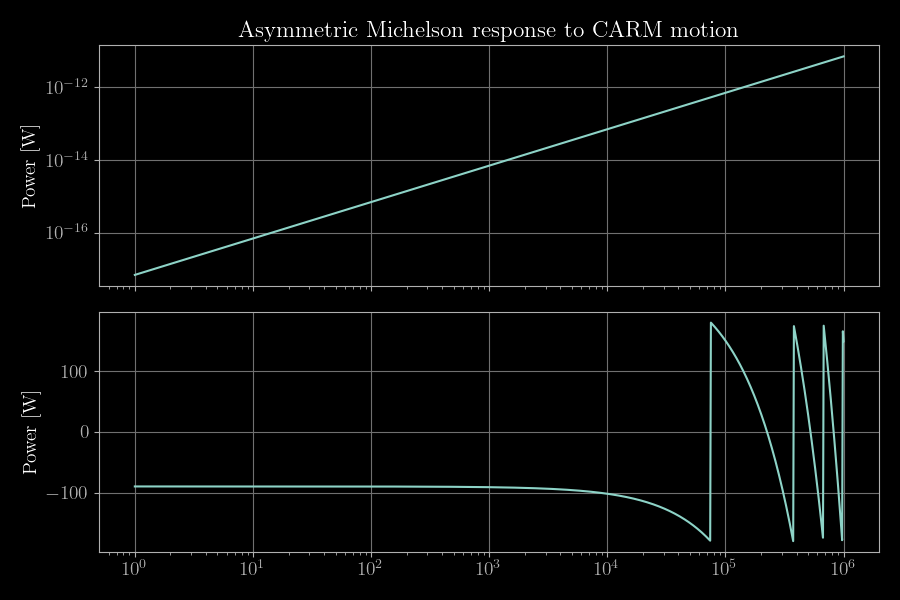

In [33]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.loglog(ff, np.abs(Pas1), label=r"DARM offset $\phi_{d0}$ = 0.1 rads")
ax2.semilogx(ff, np.angle(Pas1, deg=True), label="DARM offset = 0.1 rads")

ax1.set_title("Asymmetric Michelson response to CARM motion")
ax1.set_ylabel("Power [W]")
ax2.set_ylabel("Power [W]")
ax1.grid()
ax2.grid()

plt.show()